<a href="https://colab.research.google.com/github/raheelam98/DataAnalysis/blob/main/EDA_Projects/Zameen_EDA_Project/NoteBook/Zameen_EDA_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Zameen.com**

Tester

In [34]:
!pip install fuzzywuzzy

In [35]:
#Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
#List Files in a Folder
!ls /content/drive/MyDrive/EDA/

ai_adoption_dataset.csv  cubic_zirconia.csv		    Scarped_Zameen.xlsx
bus_fare_dataset.csv	 pakistan_intellectual_capital.csv


In [37]:
import pandas as pd

# Correct path and filename
df = pd.read_excel('/content/drive/MyDrive/EDA/Scarped_Zameen.xlsx')


In [38]:
# modules we'll use
# import pandas as pd
import numpy as np

# helpful modules
import fuzzywuzzy # pip install fuzzywuzzy
from fuzzywuzzy import process

In [39]:
df.head()

,Title,URL,City,Type,Area,Price,Purpose,Location,Description,Built in year,...,Nearby Schools,Nearby Hospitals,Nearby Shopping Malls,Nearby Restaurants,Distance From Airport (kms),Nearby Public Transport Service,Other Nearby Places,Maintenance Staff,Security Staff,Other Facilities
0,Hmr Waterfront 2 Bed Room Premium Apartment On...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chance Deal! Luxury 2 Bedroom Seafront Apartme...,https://www.zameen.com/Property/dha_defence_dh...,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Luxury 1 Bed At H& S Residence By Japanese Arc...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Luxury 1 Bed Seafront Apartment at HMR waterfr...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2 Bed Apartment For Booking On 3 Years | Saima...,https://www.zameen.com/Property/dha_phase_8_hm...,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# 2-i) View basic info
# Dataset Info : Show index range, column types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18255 entries, 0 to 18254
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Title                            18239 non-null  object 
 1   URL                              18255 non-null  object 
 2   City                             18255 non-null  object 
 3   Type                             18239 non-null  object 
 4   Area                             18239 non-null  object 
 5   Price                            18239 non-null  object 
 6   Purpose                          18239 non-null  object 
 7   Location                         18239 non-null  object 
 8   Description                      14893 non-null  object 
 9   Built in year                    11940 non-null  float64
 10  Parking Spaces                   9656 non-null   float64
 11  Double Glazed Windows            0 non-null      float64
 12  Central Air Condit

In [41]:
# Total number of rows in dataset
len(df)

18255

In [42]:
# Identify missing values using
df.isnull().sum()

,0
Title,16
URL,0
City,0
Type,16
Area,16
Price,16
Purpose,16
Location,16
Description,3362
Built in year,6315


In [43]:
# Drop All Columns with Only Missing Values
df.dropna(axis=1, how='all', inplace=True)

In [44]:
# View All Column Names
df.columns

Index(['Title', 'URL', 'City', 'Type', 'Area', 'Price', 'Purpose', 'Location',
       'Description', 'Built in year', 'Parking Spaces', 'Floors', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms'],
      dtype='object')

In [45]:
# statistical description of datafram
df.describe()

,Built in year,Parking Spaces,Floors,Servant Quarters,Kitchens,Store Rooms
count,11940.000000,9656.000000,8366.000000,9657.000000,13256.000000,9719.000000
mean,1967.123744,5.251833,2.393677,1.236823,1.686859,1.169565
std,1949.941225,41.917894,22.849369,0.706476,2.022453,0.495977
min,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2020.000000,1.000000,2.000000,1.000000,1.000000,1.000000
50%,2024.000000,2.000000,2.000000,1.000000,2.000000,1.000000
75%,2025.000000,3.000000,2.000000,1.000000,2.000000,1.000000
max,202122.000000,2015.000000,2018.000000,22.000000,211.000000,18.000000


In [46]:
# Check for total number of duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows Detected: {duplicate_count}")

# View sample duplicate entries (if any)
if duplicate_count > 0:
    print("Sample Duplicate Rows:")
    display(df[df.duplicated()].head())

# Remove duplicate rows permanently
df.drop_duplicates(inplace=True)

# Confirm removal
print(f"\n Duplicates Removed. New shape: {df.shape}")


Duplicate Rows Detected: 0

 Duplicates Removed. New shape: (18255, 17)


In [47]:
# Check for duplicates based on these columns
df.duplicated(subset=['Title', 'Area', 'Price']).sum()


np.int64(559)

In [48]:
# Drop duplicates based on key listing attributes
df.drop_duplicates(subset=['Title', 'Area', 'Price'], inplace=True)

# Confirm shape after cleanup
print(f"Clean dataset shape: {df.shape}")


Clean dataset shape: (17696, 17)


In [ ]:
# # # Categorical Column Analysis
# # print("\n\n. Categorical Column Analysis")

# for col in ['Price', 'Area']:

#     # Print column header
#     print(f"\nAnalysis for column: ' {col} ' ")

#     # Show unique values (categories present in the column)
#     print("\nUnique values:", df[col].unique())

#     # Show frequency count of each category
#     print("\nUnique Value counts:", df[col].value_counts())

#     print("---------------------------------------------")


In [49]:
print("Price Unique Values :", df['Price'].nunique()) # count of distinct values
print("Price Duplicates.   :", df['Price'].duplicated().sum())

print("\nArea Unique Values:", df['Area'].nunique()) # # count of distinct values
print("Area Duplicates:    :", df['Area'].duplicated().sum())

Price Unique Values : 1022
Price Duplicates.   : 16673

Area Unique Values: 468
Area Duplicates:    : 17227


In [50]:
print("Top 10 Price Values:\n", df['Price'].value_counts().head(10))
print("Top 10 Area Values:\n", df['Area'].value_counts().head(10))


Top 10 Price Values:
 Price
PKR\n60 Thousand    261
PKR\n45 Thousand    226
PKR\n50 Thousand    221
PKR\n70 Thousand    211
PKR\n3.5 Crore      208
PKR\n80 Thousand    204
PKR\n65 Thousand    203
PKR\n2.5 Crore      201
PKR\n55 Thousand    198
PKR\n90 Thousand    196
Name: count, dtype: int64
Top 10 Area Values:
 Area
5 Marla        3355
10 Marla       2889
1 Kanal        2047
7 Marla         847
6 Marla         445
4 Marla         412
8 Marla         354
500 Sq. Yd.     349
3 Marla         330
12 Marla        321
Name: count, dtype: int64


In [51]:
# Clean messy columns ( e.g., remove commas, PKR symbols)
import numpy as np

def clean_price_column(series):
    cleaned = (
        series.astype(str)
              .str.replace(',', '', regex=False)
              .str.replace('PKR', '', regex=False)
              .str.replace('Rs.', '', regex=False)
              .str.strip()
              .str.lower()
    )

    # Convert Lakh and Crore to numbers
    def convert_units(value):
        try:
            if 'crore' in value:
                num = float(value.replace('crore', '').strip())
                return num * 1e7
            elif 'lakh' in value:
                num = float(value.replace('lakh', '').strip())
                return num * 1e5
            else:
                return float(value)
        except:
            return np.nan

    return cleaned.apply(convert_units)


In [52]:

df['Price'] = clean_price_column(df['Price'])

# Preview result
print(df[['Price']].head())


        Price
0  47500000.0
1  62500000.0
2  34500000.0
3  29800000.0
4  46500000.0


In [53]:
# Convert area units (marla/kanal/sqft → uniform sqft), if required

def clean_area_column(series):
    unit_map = {
        'marla': 272.25,
        'kanal': 5445,
        'sq yards': 9,
        'sq. yards': 9,
        'sq meter': 10.7639,
        'sq. meter': 10.7639,
        'square meter': 10.7639,
        'sq ft': 1,
        'sq. ft': 1,
        'square feet': 1
    }

    cleaned = (
        series.astype(str)
              .str.replace(',', '', regex=False)
              .str.lower()
              .str.strip()
    )

    def convert_area(value):
        for unit in unit_map:
            if unit in value:
                try:
                    num = float(value.replace(unit, '').strip())
                    return num * unit_map[unit]
                except:
                    return np.nan
        try:
            return float(value)  # If it's already in sqft
        except:
            return np.nan

    return cleaned.apply(convert_area)


In [54]:
df['Area'] = clean_area_column(df['Area'])
df['Area'].dropna().head(10).tolist()


[1932.975,
 816.75,
 2178.0,
 2722.5,
 2722.5,
 2178.0,
 2722.5,
 1932.975,
 2994.75,
 5445.0]

In [ ]:
# # Categorical Column Analysis
# print("\n\n. Categorical Column Analysis")

# for col in df.columns:

#     # Print column header
#     print(f"\nAnalysis for column: ' {col} ' ")

#     # Show unique values (categories present in the column)
#     print("\nUnique values:", df[col].unique())

#     # Show frequency count of each category
#     print("\nUnique Value counts:", df[col].value_counts())

#     print("---------------------------------------------")


In [55]:
# Integer count of distinct values
for column in df:
    print(column,df[column].nunique())


Title 16064
URL 17696
City 83
Type 7
Area 216
Price 904
Purpose 2
Location 1048
Description 13437
Built in year 95
Parking Spaces 46
Floors 20
Bedrooms 23
Bathrooms 17
Servant Quarters 14
Kitchens 10
Store Rooms 10


In [56]:
# 3. Missing Values Treatment

# Missing Values - Function
import pandas as pd

def check_missing_values(df):
    """
    Returns a DataFrame summarizing missing values in the input DataFrame.

    Columns:
    - 'Missing Values': total number of missing values in each column
    - 'Percentage (%)': percentage of missing values in each column
    """
    # 1. Total missing values in each column
    missing_counts = df.isnull().sum()

    # 2. Percentage of missing values
    missing_percent = (missing_counts / len(df)) * 100

    # 3. Combine into a single DataFrame
    missing_summary = pd.DataFrame({
        'Missing Values': missing_counts,
        'Percentage (%)': missing_percent.round(2)
    })

    # 4. Filter only columns with missing values
    missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

    return missing_summary

# calling function
print("\n\nSummary of Missing Values:")

missing_info = check_missing_values(df)
print(missing_info)



Summary of Missing Values:
                  Missing Values  Percentage (%)
Title                          1            0.01
Type                           1            0.01
Area                        2803           15.84
Price                       3480           19.67
Purpose                        1            0.01
Location                       1            0.01
Description                 3255           18.39
Built in year               6081           34.36
Parking Spaces              8266           46.71
Floors                      9593           54.21
Bedrooms                       1            0.01
Bathrooms                      1            0.01
Servant Quarters            8313           46.98
Kitchens                    4818           27.23
Store Rooms                 8223           46.47


In [58]:
# column names
print(df.columns.tolist())


['Title', 'URL', 'City', 'Type', 'Area', 'Price', 'Purpose', 'Location', 'Description', 'Built in year', 'Parking Spaces', 'Floors', 'Bedrooms', 'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms']


In [ ]:
# Check Missing Values (before filling)
print(df[['City', 'Price']].isnull().sum())


In [74]:
# Fix column names with whitespace
df.columns = df.columns.str.strip()

# Categorical Column
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Numerical Column
df['Price'] = df['Price'].fillna(df['Price'].mean())

# Only do this if 'posting_date' exists
if 'posting_date' in df.columns:
    df['posting_date'] = df['posting_date'].fillna(method='ffill')


In [71]:
# confirm the exact value that was used for imputation
print("Used mode for City:", df['City'].mode()[0])

print("Used mean for Price:", df['Price'].mean())


Used mean for Price: 36945247.819358476
Used mode for City: Karachi


In [68]:
# Check Missing Values (after filling)
print(df[['City', 'Price']].isnull().sum())


City     0
Price    0
dtype: int64


In [70]:
# Summary Statistics : To see whether the mean price was correctly used
df['Price'].describe()


,Price
count,1.769600e+04
mean,3.694525e+07
std,6.102265e+07
min,1.000000e+05
25%,1.050000e+07
50%,2.805000e+07
75%,3.694525e+07
max,9.900000e+08


In [72]:
#  Show If 'posting_date' Was Processed : To confirm if the column exists and was filled:
if 'posting_date' in df.columns:
    print(df['posting_date'].isnull().sum())
    print(df['posting_date'].head())
else:
    print("No 'posting_date' column found.")


No 'posting_date' column found.


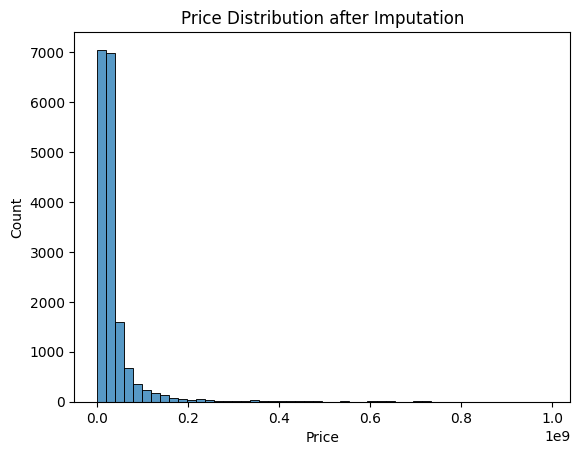

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], bins=50)
plt.title('Price Distribution after Imputation')
plt.show()
